## 1. Setup and file checks

This notebook creates the spatial visualization layer for the AI Literacy Gap Index. The goal is to connect the final regional index output with official NUTS-1 geometries, validate the spatial join, and prepare reproducible map outputs for reporting and possible web publication.

In this first step, I set up the required paths and check whether the final clustered index file from the previous notebook is available.

In [1]:
from pathlib import Path
import pandas as pd

# Detect project root whether the notebook is run from /notebooks or the repository root
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

# Project paths
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
GEO_DIR = DATA_DIR / "geo"
WEB_DATA_DIR = PROJECT_ROOT / "web" / "data"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

# Create output folders if they do not exist yet
for path in [GEO_DIR, WEB_DATA_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Search for the final clustered index output from the previous notebook
candidate_files = sorted(PROJECT_ROOT.rglob("ai_literacy_gap_index_clustered.csv"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Geo output folder: {GEO_DIR}")
print(f"Web data output folder: {WEB_DATA_DIR}")
print(f"Figures output folder: {FIGURES_DIR}")
print("\nCandidate final index files:")

for file in candidate_files:
    print(f"- {file.relative_to(PROJECT_ROOT)}")

if len(candidate_files) == 0:
    raise FileNotFoundError(
        "Could not find 'ai_literacy_gap_index_clustered.csv'. "
        "Please run the previous notebooks first or check the filename."
    )

if len(candidate_files) > 1:
    print(
        "\nWarning: More than one candidate file was found. "
        "For now, the first sorted file will be used. Please verify this is correct."
    )

INDEX_PATH = candidate_files[0]

index_df = pd.read_csv(INDEX_PATH)

print(f"\nUsing index file: {INDEX_PATH.relative_to(PROJECT_ROOT)}")
print(f"Shape: {index_df.shape}")
print("\nColumns:")
print(index_df.columns.tolist())

display(index_df.head())

Project root: c:\Users\Lu\OneDrive\ToU\chl_data_science_project
Geo output folder: c:\Users\Lu\OneDrive\ToU\chl_data_science_project\data\geo
Web data output folder: c:\Users\Lu\OneDrive\ToU\chl_data_science_project\web\data
Figures output folder: c:\Users\Lu\OneDrive\ToU\chl_data_science_project\reports\figures

Candidate final index files:
- data\processed\ai_literacy_gap_index_clustered.csv

Using index file: data\processed\ai_literacy_gap_index_clustered.csv
Shape: (87, 15)

Columns:
['rank', 'geo', 'country', 'nuts1_name', 'ai_literacy_gap_index', 'baseline_score', 'pillars_available', 'P1_norm', 'P2_norm', 'P3_norm', 'P4_norm', 'P5_norm', 'P6_norm', 'cluster_id', 'cluster_label']


,rank,geo,country,nuts1_name,ai_literacy_gap_index,baseline_score,pillars_available,P1_norm,P2_norm,P3_norm,P4_norm,P5_norm,P6_norm,cluster_id,cluster_label
0,1,ITG,Italy,Isole,0.730699,0.722121,6,0.650826,0.971131,0.748593,0.856757,0.353801,0.751617,0,Education & Poverty Trap
1,2,ITF,Italy,Sud,0.699806,0.691378,6,0.717114,0.869221,0.677298,0.851351,0.350877,0.682406,0,Education & Poverty Trap
2,3,BG3,Bulgaria,Severna i Yugoiztochna Bulgaria,0.651487,0.648244,6,0.860537,0.717367,0.242026,0.918919,0.336257,0.814360,3,Digital & Retraining Deficit
3,4,RO2,Romania,Macroregiunea Doi,0.647873,0.639589,6,0.934229,0.743798,0.425891,0.827027,0.441520,0.465071,3,Digital & Retraining Deficit
4,5,FRY,France,RUP FR — Régions Ultrapériphériques Françaises,0.642841,0.627648,6,0.605372,1.000000,0.572233,0.816216,0.587719,0.184347,0,Education & Poverty Trap


## 2. Download and inspect NUTS-1 geometries

To visualize the AI Literacy Gap Index spatially, I use the official Eurostat GISCO NUTS-1 geometries. The geometries are downloaded in GeoJSON format with WGS84 coordinates, which makes them suitable for both Python-based mapping and later web publication.

At this stage, I only inspect the geometry file and its attributes. The join with the index data is handled in the next step.

In [3]:
from pathlib import Path
import pandas as pd

# GeoPandas is required for spatial data handling
try:
    import geopandas as gpd
except ImportError as e:
    raise ImportError(
        "GeoPandas is not installed in this environment. "
        "Install it first, for example with: pip install geopandas"
    ) from e

# Recreate paths so this notebook remains self-contained
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
GEO_DIR = DATA_DIR / "geo"
GEO_DIR.mkdir(parents=True, exist_ok=True)

# Official Eurostat GISCO NUTS 2024 NUTS-1 GeoJSON, EPSG:4326, 1:1 million scale
NUTS_YEAR = 2024
NUTS_LEVEL = 1
NUTS_SCALE = "01M"
NUTS_EPSG = 4326

NUTS_URL = (
    f"https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
    f"NUTS_RG_{NUTS_SCALE}_{NUTS_YEAR}_{NUTS_EPSG}_LEVL_{NUTS_LEVEL}.geojson"
)

NUTS_GEO_PATH = GEO_DIR / f"nuts{NUTS_LEVEL}_{NUTS_YEAR}_{NUTS_EPSG}_{NUTS_SCALE}.geojson"

# Download only if the file does not already exist locally
if not NUTS_GEO_PATH.exists():
    print("Downloading NUTS geometry file...")
    nuts_gdf = gpd.read_file(NUTS_URL)
    nuts_gdf.to_file(NUTS_GEO_PATH, driver="GeoJSON")
else:
    print("Using existing local NUTS geometry file.")
    nuts_gdf = gpd.read_file(NUTS_GEO_PATH)

print(f"Geometry file: {NUTS_GEO_PATH.relative_to(PROJECT_ROOT)}")
print(f"Shape: {nuts_gdf.shape}")
print(f"CRS: {nuts_gdf.crs}")

print("\nColumns:")
print(nuts_gdf.columns.tolist())

print("\nFirst rows:")
display(nuts_gdf.head())

print("\nNUTS level distribution:")
display(nuts_gdf["LEVL_CODE"].value_counts().sort_index())

print("\nCountries / country codes included:")
display(
    nuts_gdf["CNTR_CODE"]
    .value_counts()
    .sort_index()
    .rename_axis("country_code")
    .reset_index(name="n_regions")
)

Geometry file: data\geo\nuts1_2024_4326_01M.geojson
Shape: (115, 18)
CRS: EPSG:4326

Columns:
['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE', 'SVRG_UN', 'CAPT', 'EU_STAT', 'EFTA_STAT', 'CC_STAT', 'NAME_GERM', 'geometry']

First rows:


,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,NAME_ENGL,NAME_FREN,ISO3_CODE,SVRG_UN,CAPT,EU_STAT,EFTA_STAT,CC_STAT,NAME_GERM,geometry
0,DEF,1,DE,Schleswig-Holstein,Schleswig-Holstein,NaN,None,None,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((8.636 54.91157, 8.65858 54.908..."
1,DE2,1,DE,Bayern,Bayern,NaN,None,None,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((10.45102 47.5546, 10.45444 47...."
2,DE3,1,DE,Berlin,Berlin,NaN,None,None,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((13.4865 52.66883, 13.48648 52...."
3,DEG,1,DE,Thüringen,Thüringen,NaN,None,None,Germany,Allemagne,DEU,UN Member State,Berlin,T,F,F,Deutschland,"MULTIPOLYGON (((10.78569 51.64202, 10.80489 51..."
4,EL4,1,EL,"Nisia Aigaiou, Kriti","Νησιά Αιγαίου, Κρήτη",NaN,None,None,Greece,Grèce,GRC,UN Member State,Athens,T,F,F,Griechenland,"MULTIPOLYGON (((24.13069 34.80711, 24.12051 34..."



NUTS level distribution:


LEVL_CODE
1    115
Name: count, dtype: int64


Countries / country codes included:


,country_code,n_regions
0,AL,1
1,AT,3
2,BA,1
3,BE,3
4,BG,2
5,CH,1
6,CY,1
7,CZ,1
8,DE,16
9,DK,1


## 3. Join index data to NUTS-1 geometries

In this step, I join the final AI Literacy Gap Index table to the official NUTS-1 geometry layer. The join is based on the NUTS region code. I keep all EU27 NUTS-1 geometries so that regions without index values can still be shown on the map as missing data.

Before mapping, I check whether all index regions match a geometry and which NUTS-1 geometries do not have index data.

In [4]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# Recreate paths so this notebook remains self-contained
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
GEO_DIR = DATA_DIR / "geo"
WEB_DATA_DIR = PROJECT_ROOT / "web" / "data"

GEO_DIR.mkdir(parents=True, exist_ok=True)
WEB_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Load final clustered index file
index_candidates = sorted(PROJECT_ROOT.rglob("ai_literacy_gap_index_clustered.csv"))

if not index_candidates:
    raise FileNotFoundError(
        "Could not find ai_literacy_gap_index_clustered.csv. "
        "Please check whether 04_clustering.ipynb saved the final output."
    )

INDEX_PATH = index_candidates[0]
index_df = pd.read_csv(INDEX_PATH)

# Load NUTS-1 geometry file
geo_candidates = sorted(GEO_DIR.glob("*LEVL_1*.geojson")) + sorted(GEO_DIR.glob("nuts1*.geojson"))

if not geo_candidates:
    raise FileNotFoundError(
        "Could not find a local NUTS-1 GeoJSON file in data/geo. "
        "Please run Step 2 first."
    )

NUTS_GEO_PATH = geo_candidates[0]
nuts_gdf = gpd.read_file(NUTS_GEO_PATH)

print(f"Using index file: {INDEX_PATH.relative_to(PROJECT_ROOT)}")
print(f"Using geometry file: {NUTS_GEO_PATH.relative_to(PROJECT_ROOT)}")

# Standardize join keys
index_df["geo"] = index_df["geo"].astype(str).str.strip()
nuts_gdf["NUTS_ID"] = nuts_gdf["NUTS_ID"].astype(str).str.strip()

# EU27 country codes
EU27_CODES = [
    "AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI",
    "FR", "DE", "EL", "HU", "IE", "IT", "LV", "LT", "LU",
    "MT", "NL", "PL", "PT", "RO", "SK", "SI", "ES", "SE"
]

# Keep only EU27 NUTS-1 geometries
nuts1_eu27_gdf = nuts_gdf[
    (nuts_gdf["LEVL_CODE"] == 1) &
    (nuts_gdf["CNTR_CODE"].isin(EU27_CODES))
].copy()

# Check for duplicate join keys before joining
index_duplicates = index_df[index_df["geo"].duplicated(keep=False)]
geometry_duplicates = nuts1_eu27_gdf[nuts1_eu27_gdf["NUTS_ID"].duplicated(keep=False)]

print("\nDuplicate region codes in index data:", len(index_duplicates))
print("Duplicate region codes in geometry data:", len(geometry_duplicates))

if len(index_duplicates) > 0:
    display(index_duplicates.sort_values("geo"))

if len(geometry_duplicates) > 0:
    display(geometry_duplicates.sort_values("NUTS_ID"))

# Join: keep all EU27 geometries so missing regions can be greyed out later
map_gdf = nuts1_eu27_gdf.merge(
    index_df,
    how="left",
    left_on="NUTS_ID",
    right_on="geo",
    indicator=True
)

map_gdf["has_index_data"] = map_gdf["ai_literacy_gap_index"].notna()

# Regions in the index file that did not match a NUTS-1 geometry
unmatched_index_regions = index_df[
    ~index_df["geo"].isin(nuts1_eu27_gdf["NUTS_ID"])
].copy()

# EU27 NUTS-1 geometries without index data
missing_geometry_regions = map_gdf[
    map_gdf["has_index_data"] == False
][["NUTS_ID", "CNTR_CODE", "NAME_LATN"]].copy()

print("\nJoin summary")
print(f"EU27 NUTS-1 geometries: {len(nuts1_eu27_gdf)}")
print(f"Index rows: {len(index_df)}")
print(f"Matched geometries with index data: {map_gdf['has_index_data'].sum()}")
print(f"Geometries without index data: {(~map_gdf['has_index_data']).sum()}")
print(f"Index rows without geometry match: {len(unmatched_index_regions)}")

print("\nIndex rows without geometry match:")
display(unmatched_index_regions[["geo", "country", "nuts1_name"]])

print("\nEU27 NUTS-1 geometries without index data:")
display(missing_geometry_regions.sort_values(["CNTR_CODE", "NUTS_ID"]))

# Save joined spatial working file for later mapping steps
JOINED_GEO_PATH = GEO_DIR / "nuts1_2024_eu27_ai_literacy_gap_joined.geojson"
map_gdf.to_file(JOINED_GEO_PATH, driver="GeoJSON")

print(f"\nSaved joined geometry file to: {JOINED_GEO_PATH.relative_to(PROJECT_ROOT)}")

Using index file: data\processed\ai_literacy_gap_index_clustered.csv
Using geometry file: data\geo\nuts1_2024_4326_01M.geojson

Duplicate region codes in index data: 0
Duplicate region codes in geometry data: 0

Join summary
EU27 NUTS-1 geometries: 92
Index rows: 87
Matched geometries with index data: 87
Geometries without index data: 5
Index rows without geometry match: 0

Index rows without geometry match:


,geo,country,nuts1_name



EU27 NUTS-1 geometries without index data:


,NUTS_ID,CNTR_CODE,NAME_LATN
6,DE5,DE,Bremen
12,DEB,DE,Rheinland-Pfalz
15,DEC,DE,Saarland
3,DEG,DE,Thüringen
44,FI2,FI,Åland



Saved joined geometry file to: data\geo\nuts1_2024_eu27_ai_literacy_gap_joined.geojson


The spatial join between the final AI Literacy Gap Index and the official NUTS-1 geometries was successful. All 87 regions in the index table matched a corresponding NUTS-1 geometry, so there are no unresolved region-code mismatches.

The official EU27 NUTS-1 geometry layer contains 92 regions, while the final index covers 87 regions. Five NUTS-1 regions do not have index values and are therefore retained as missing observations in the spatial layer. This is important for the map design, because these regions should not be dropped silently but shown in grey to communicate limited data availability transparently.

## 4. Inspect spatial extent before mapping

Before creating the first validation map, I inspect the spatial extent of the joined NUTS-1 layer. This is necessary because some EU NUTS-1 regions are geographically outside mainland Europe. If these regions are included in the same automatic map extent, the European part of the map may become too small to interpret.

This step identifies regions whose centroids fall outside a broad mainland-Europe bounding box. The result will guide the map design decision in the next step.

In [5]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# Recreate paths so this notebook remains self-contained
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

GEO_DIR = PROJECT_ROOT / "data" / "geo"

JOINED_GEO_PATH = GEO_DIR / "nuts1_2024_eu27_ai_literacy_gap_joined.geojson"

if not JOINED_GEO_PATH.exists():
    raise FileNotFoundError(
        "Could not find the joined GeoJSON file. Please run the previous join step first."
    )

map_gdf = gpd.read_file(JOINED_GEO_PATH)

# Ensure WGS84 coordinates for longitude/latitude checks
if map_gdf.crs is None:
    raise ValueError("The joined GeoDataFrame has no CRS. Please check the geometry file.")

map_gdf = map_gdf.to_crs(epsg=4326)

# Use representative points instead of centroids because they are guaranteed to fall inside polygons
map_gdf["rep_point"] = map_gdf.geometry.representative_point()
map_gdf["rep_lon"] = map_gdf["rep_point"].x
map_gdf["rep_lat"] = map_gdf["rep_point"].y

# Broad mainland-Europe extent for diagnostic purposes only
EUROPE_LON_MIN, EUROPE_LON_MAX = -25, 45
EUROPE_LAT_MIN, EUROPE_LAT_MAX = 34, 72

map_gdf["outside_mainland_europe_extent"] = ~(
    map_gdf["rep_lon"].between(EUROPE_LON_MIN, EUROPE_LON_MAX)
    & map_gdf["rep_lat"].between(EUROPE_LAT_MIN, EUROPE_LAT_MAX)
)

outside_extent = map_gdf[
    map_gdf["outside_mainland_europe_extent"]
][
    [
        "NUTS_ID",
        "CNTR_CODE",
        "NAME_LATN",
        "has_index_data",
        "ai_literacy_gap_index",
        "cluster_label",
        "rep_lon",
        "rep_lat",
    ]
].copy()

print("Joined map layer shape:", map_gdf.shape)
print("CRS:", map_gdf.crs)

print("\nTotal bounds of full geometry layer:")
print(map_gdf.total_bounds)

print("\nRegions outside the broad mainland-Europe extent:")
display(
    outside_extent
    .sort_values(["CNTR_CODE", "NUTS_ID"])
    .reset_index(drop=True)
)

print("\nCount by index-data availability:")
display(
    map_gdf
    .groupby(["outside_mainland_europe_extent", "has_index_data"])
    .size()
    .reset_index(name="n_regions")
)

Joined map layer shape: (92, 39)
CRS: EPSG:4326

Total bounds of full geometry layer:
[-63.15118762 -21.38890872  55.83576577  70.09173206]

Regions outside the broad mainland-Europe extent:


,NUTS_ID,CNTR_CODE,NAME_LATN,has_index_data,ai_literacy_gap_index,cluster_label,rep_lon,rep_lat
0,ES7,ES,Canarias,True,0.523843,Education & Poverty Trap,-16.620663,28.295099
1,FRY,FR,RUP FR — Régions Ultrapériphériques Françaises,True,0.642841,Education & Poverty Trap,-53.033592,3.930568
2,PT2,PT,Região Autónoma dos Açores,True,0.526845,Education & Poverty Trap,-25.472393,37.807282
3,PT3,PT,Região Autónoma da Madeira,True,0.613644,Education & Poverty Trap,-16.982496,32.752565



Count by index-data availability:


,outside_mainland_europe_extent,has_index_data,n_regions
0,False,False,5
1,False,True,83
2,True,True,4


The joined NUTS-1 map layer contains all 92 EU27 NUTS-1 geometries. However, the total spatial extent shows that some regions are located far outside mainland Europe. These are Canarias, the French outermost regions, Açores, and Madeira. All four regions have valid AI Literacy Gap Index values, so they are not missing from the dataset.

For the first validation map, I use a mainland-Europe view to keep the regional pattern readable. The four outermost regions remain part of the joined spatial dataset but are not shown in the main map extent. To keep this transparent, I document them separately below the map instead of silently dropping them from the analysis.

Missing NUTS-1 regions within the mainland-Europe view are kept in the geometry layer and will be shown in grey. This ensures that data gaps are visible in the map rather than hidden by filtering.

## 4. Static validation map

In this step, I create the first static validation map of the AI Literacy Gap Index. The map focuses on mainland Europe so that the regional pattern remains readable. NUTS-1 regions without index data are kept in the geometry layer and shown in grey.

The four outermost regions outside the mainland-Europe extent are documented separately below the map. They remain part of the dataset and can still be included in later interactive or web-based versions.

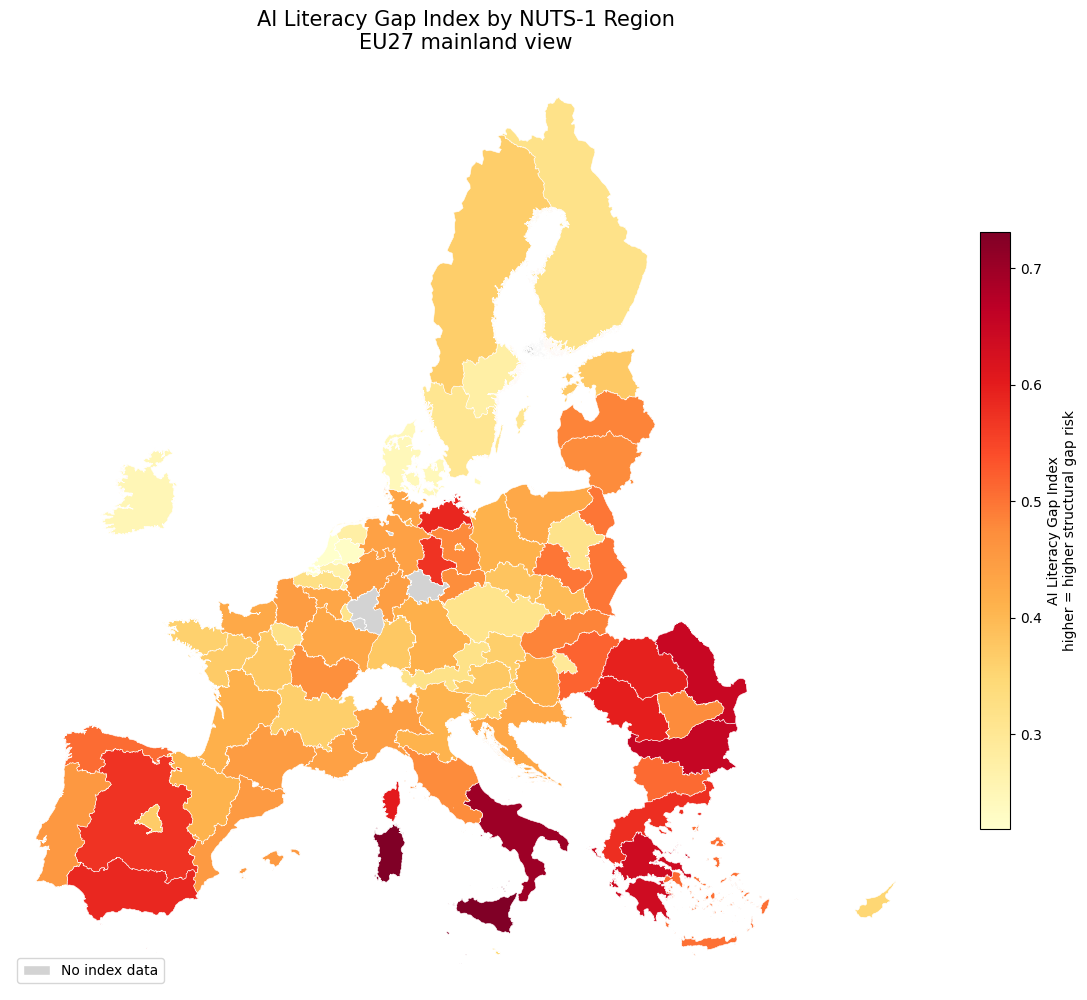

Saved static map to: reports\figures\ai_literacy_gap_static_map_mainland.png

Outermost regions not shown in the mainland-Europe map extent:


,NUTS_ID,CNTR_CODE,NAME_LATN,ai_literacy_gap_index,cluster_label
0,ES7,ES,Canarias,0.523843,Education & Poverty Trap
1,FRY,FR,RUP FR — Régions Ultrapériphériques Françaises,0.642841,Education & Poverty Trap
2,PT2,PT,Região Autónoma dos Açores,0.526845,Education & Poverty Trap
3,PT3,PT,Região Autónoma da Madeira,0.613644,Education & Poverty Trap


Saved outermost-region table to: reports\figures\outermost_regions_not_shown_mainland_map.csv


In [6]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Recreate paths so this notebook remains self-contained
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

GEO_DIR = PROJECT_ROOT / "data" / "geo"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

JOINED_GEO_PATH = GEO_DIR / "nuts1_2024_eu27_ai_literacy_gap_joined.geojson"

if not JOINED_GEO_PATH.exists():
    raise FileNotFoundError(
        "Could not find the joined GeoJSON file. Please run the spatial join step first."
    )

# Load joined spatial layer
map_gdf = gpd.read_file(JOINED_GEO_PATH).to_crs(epsg=4326)

# Ensure the index column is numeric
index_col = "ai_literacy_gap_index"

if index_col not in map_gdf.columns:
    raise KeyError(f"Expected column '{index_col}' was not found in the joined map layer.")

map_gdf[index_col] = pd.to_numeric(map_gdf[index_col], errors="coerce")

# Recreate mainland-Europe extent flag
map_gdf["rep_point"] = map_gdf.geometry.representative_point()
map_gdf["rep_lon"] = map_gdf["rep_point"].x
map_gdf["rep_lat"] = map_gdf["rep_point"].y

EUROPE_LON_MIN, EUROPE_LON_MAX = -25, 45
EUROPE_LAT_MIN, EUROPE_LAT_MAX = 34, 72

map_gdf["outside_mainland_europe_extent"] = ~(
    map_gdf["rep_lon"].between(EUROPE_LON_MIN, EUROPE_LON_MAX)
    & map_gdf["rep_lat"].between(EUROPE_LAT_MIN, EUROPE_LAT_MAX)
)

# Split map layer into mainland view and outermost regions
mainland_gdf = map_gdf[~map_gdf["outside_mainland_europe_extent"]].copy()
outermost_gdf = map_gdf[map_gdf["outside_mainland_europe_extent"]].copy()

# Project to European equal-area projection for a cleaner static map
mainland_plot_gdf = mainland_gdf.to_crs(epsg=3035)

# Create static map
fig, ax = plt.subplots(figsize=(12, 10))

mainland_plot_gdf.plot(
    column=index_col,
    ax=ax,
    cmap="YlOrRd",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No index data",
    },
    legend_kwds={
        "label": "AI Literacy Gap Index\nhigher = higher structural gap risk",
        "shrink": 0.65,
    },
)

# Add a separate legend item for missing data
missing_patch = Patch(
    facecolor="lightgrey",
    edgecolor="white",
    label="No index data"
)
ax.legend(handles=[missing_patch], loc="lower left", frameon=True)

ax.set_title(
    "AI Literacy Gap Index by NUTS-1 Region\nEU27 mainland view",
    fontsize=15,
    pad=16,
)

ax.set_axis_off()

# Set map bounds with a small buffer
minx, miny, maxx, maxy = mainland_plot_gdf.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax.set_xlim(minx - x_buffer, maxx + x_buffer)
ax.set_ylim(miny - y_buffer, maxy + y_buffer)

plt.tight_layout()

# Save figure
STATIC_MAP_PATH = FIGURES_DIR / "ai_literacy_gap_static_map_mainland.png"
plt.savefig(STATIC_MAP_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved static map to: {STATIC_MAP_PATH.relative_to(PROJECT_ROOT)}")

# Document outermost regions not shown in the mainland map extent
outermost_columns = [
    "NUTS_ID",
    "CNTR_CODE",
    "NAME_LATN",
    "ai_literacy_gap_index",
    "cluster_label",
]

available_outermost_columns = [
    col for col in outermost_columns
    if col in outermost_gdf.columns
]

outermost_table = (
    outermost_gdf[available_outermost_columns]
    .sort_values(["CNTR_CODE", "NUTS_ID"])
    .reset_index(drop=True)
)

print("\nOutermost regions not shown in the mainland-Europe map extent:")
display(outermost_table)

OUTERMOST_TABLE_PATH = FIGURES_DIR / "outermost_regions_not_shown_mainland_map.csv"
outermost_table.to_csv(OUTERMOST_TABLE_PATH, index=False)

print(f"Saved outermost-region table to: {OUTERMOST_TABLE_PATH.relative_to(PROJECT_ROOT)}")

The first static map confirms that the AI Literacy Gap Index can be successfully joined to the official NUTS-1 geometries. All indexed regions are displayed spatially, while NUTS-1 regions without sufficient index data are retained and shown in grey.

The map shows a visible regional pattern, with higher structural AI-literacy-gap risk concentrated in parts of Southern and South-Eastern Europe. Lower-risk regions are more common in parts of Northern and Western Europe. This pattern should be interpreted as a proxy-based structural risk pattern rather than a direct measurement of individual AI literacy.

For readability, the map uses a mainland-Europe view. The four outermost regions outside this extent are not shown in the main map, but they remain part of the dataset and are documented separately below the figure.